# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros

**Curso:** ISIS2611
**Integrantes:** David Lucuara-202410218 — Jose Pardo-202411790

> **Propósito:** comparar regresión polinomial y regularizada (Ridge y Lasso) para estimar la temperatura máxima del día siguiente, seleccionar el mejor modelo mediante validación cruzada y cuantificar la incertidumbre de sus métricas mediante bootstrapping.


## Tabla de contenido

1. Contexto y continuidad con el Laboratorio 1
2. Configuración del entorno
3. Carga de datos
4. Preparación de los datos
5. Modelo 1 — Regresión polinomial
6. Curvas de validación
7. Modelos regularizados — Ridge y Lasso
8. Modelo polinomial regularizado
9. Comparación y selección del mejor modelo
10. Intervalos de confianza (bootstrapping)
11. Análisis de resultados
12. Conclusiones
13. Guion del video
14. Uso de herramientas de IA generativa


# 1. Contexto y continuidad con el Laboratorio 1

En el Laboratorio 1 se construyó un primer modelo de regresión lineal para AlpesPlanck (`temp_max_manana` como variable objetivo, una fila por día) y se seleccionó como mejor modelo la variante con codificación cíclica de la estacionalidad (`dia_seno`/`dia_coseno`) y descomposición vectorial de la dirección del viento (`viento_norte`/`viento_este`).

Este laboratorio reutiliza el mismo conjunto de datos y las mismas reglas de limpieza determinística definidas y justificadas en el Laboratorio 1 (normalización de texto, corrección de errores de escala, valores centinela, coherencia `mínimo <= media <= máximo`, etc.). Por esa razón, la exploración y el análisis de calidad de datos no se repiten aquí; la sección 4 únicamente reproduce la limpieza ya validada para dejar `X_train`, `X_test`, `y_train` y `y_test` listos para el modelado, que es el énfasis de este laboratorio.

# 2. Configuración del entorno

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, validation_curve
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


In [3]:
# Semilla y constantes del laboratorio (idénticas al Laboratorio 1 para mantener comparabilidad).
RANDOM_STATE = 42
TEST_SIZE = 0.25
N_SPLITS_CV = 5
N_BOOTSTRAP = 500


# 3. Carga de datos

Se utiliza el mismo archivo de entrenamiento etiquetado del Laboratorio 1. El diccionario de datos se carga como referencia para la interpretación de variables en las secciones de análisis.

In [4]:
# cargar los datos de entrenamiento (mismo archivo utilizado en el Laboratorio 1).
data_clima = pd.read_csv("./data/Datos Lab 1.csv")
data = data_clima.copy()

print("Dimensiones originales:", data.shape)
data.head()


Dimensiones originales: (2576, 27)


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [5]:
# diccionario de datos, como referencia para la interpretación de variables más adelante.
diccionario_datos = pd.read_excel("./data/Diccionario de datos.xlsx")
diccionario_datos.head(27)


,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


# 4. Preparación de los datos

## 4.1 Limpieza determinística

Se reaplican, sin repetir su exploración ni justificación (ver Laboratorio 1, sección 5 y 6.1), las mismas reglas de calidad: normalización de texto, eliminación de duplicados exactos, conversión de valores centinela a ausentes, corrección de errores de escala, validación de coherencia `mínimo <= media <= máximo`, reconstrucción de `mes`/`estación` desde `fecha` y armonización de `sector_viento`.

In [6]:
# --- normalización de texto y fecha ---
data["fecha"] = pd.to_datetime(data["fecha"], errors="coerce")

for columna in ["estacion_anio", "mes"]:
    data[columna] = data[columna].astype("string").str.strip().str.lower()

data["sector_viento"] = data["sector_viento"].astype("string").str.strip().str.upper()


In [7]:
# --- duplicados exactos ---
print("Duplicados antes:", data.duplicated().sum())
data = data.drop_duplicates().copy()
print("Duplicados después:", data.duplicated().sum())


Duplicados antes: 4
Duplicados después: 0


In [8]:
# --- valores físicamente imposibles (centinela y signos inválidos) ---
columnas_numericas_todas = data.select_dtypes(include="number").columns.tolist()
data[columnas_numericas_todas] = data[columnas_numericas_todas].mask(data[columnas_numericas_todas] <= -999)

# las desviaciones no pueden ser negativas
for columna in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
    data.loc[data[columna] < 0, columna] = np.nan

# velocidades y ráfagas no pueden ser negativas
for columna in ["viento_min", "viento_media", "viento_max",
                "rafaga_min", "rafaga_media", "rafaga_max"]:
    data.loc[data[columna] < 0, columna] = np.nan


In [10]:
# --- errores de escala ---
columnas_presion = ["presion_media", "presion_min", "presion_max"]

# presión ~9900 mbar = error de factor 10 (rango físico en Jena: ~950-1050).
for columna in columnas_presion:
    mascara = data[columna] > 1100
    data.loc[mascara, columna] = data.loc[mascara, columna] / 10
    data.loc[~data[columna].between(900, 1100), columna] = np.nan

columnas_humedad = ["humedad_media", "humedad_min", "humedad_max"]

# humedad expresada como fracción (0-1) en vez de porcentaje.
for columna in columnas_humedad:
    mascara = data[columna] <= 1.5
    data.loc[mascara, columna] = data.loc[mascara, columna] * 100
    data.loc[data[columna] < 10, columna] = np.nan

# máximo físico de mediciones de 10 minutos en un día.
data.loc[data["registros_del_dia"] > 144, "registros_del_dia"] = np.nan


In [11]:
# --- coherencia de las desviaciones típicas ---
pares_desviacion = [
    ("viento_desv", "viento_max"),
    ("rafaga_desv", "rafaga_max"),
]

for col_desv, col_max in pares_desviacion:
    incoherente = (
        data[[col_desv, col_max]].notna().all(axis=1)
        & (data[col_desv] > data[col_max])
    )
    data.loc[incoherente, col_desv] = np.nan

data.loc[data["presion_desv"] > 50, "presion_desv"] = np.nan
data.loc[~data["humedad_desv"].between(0, 50), "humedad_desv"] = np.nan

# valor extremo evidente de registro; 50 m/s como límite superior conservador.
data.loc[data["viento_desv"] > 50, "viento_desv"] = np.nan


In [12]:
# --- coherencia mínimo <= media <= máximo ---
# si la tripleta es incoherente no se sabe cuál de los tres valores está mal;
# se marcan los tres como ausentes y el imputador del pipeline los resuelve.
tripletas = {
    "presion": ["presion_min", "presion_media", "presion_max"],
    "humedad": ["humedad_min", "humedad_media", "humedad_max"],
    "viento":  ["viento_min", "viento_media", "viento_max"],
    "rafaga":  ["rafaga_min", "rafaga_media", "rafaga_max"],
}

for nombre, (col_min, col_med, col_max) in tripletas.items():
    incoherente = (
        data[[col_min, col_med, col_max]].notna().all(axis=1)
        & ((data[col_min] > data[col_med]) | (data[col_med] > data[col_max]))
    )
    data.loc[incoherente, [col_min, col_med, col_max]] = np.nan


In [13]:
# --- reconstrucción de mes y estación desde la fecha ---
data["mes_num"] = data["fecha"].dt.month
data["dia_del_anio"] = data["dia_del_anio"].fillna(data["fecha"].dt.dayofyear)
data["anio"] = data["anio"].fillna(data["fecha"].dt.year)

estaciones_hemisferio_norte = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}
data["estacion_reconstruida"] = data["mes_num"].map(estaciones_hemisferio_norte)

# --- armonización de sector_viento ---
mapa_sector = {
    "N": "N", "NORTH": "N", "NORTE": "N",
    "S": "S", "SOUTH": "S", "SUR": "S",
    "E": "E", "EAST": "E", "ESTE": "E",
    "O": "O", "WEST": "O", "OESTE": "O",
    "NE": "NE", "NORTHEAST": "NE", "NORESTE": "NE",
    "NO": "NO", "NORTHWEST": "NO", "NOROESTE": "NO",
    "SE": "SE", "SOUTHEAST": "SE", "SURESTE": "SE",
    "SO": "SO", "SOUTHWEST": "SO", "SUROESTE": "SO",
}
data["sector_viento"] = data["sector_viento"].map(mapa_sector)


In [14]:
# --- valores imposibles y ausentes en el objetivo ---
# récord histórico de Jena ~ 38-39 °C.
data.loc[~data["temp_max_manana"].between(-30, 40), "temp_max_manana"] = np.nan

filas_antes = data.shape[0]
data = data.dropna(subset=["temp_max_manana"]).copy()
print(f"Filas eliminadas por objetivo ausente: {filas_antes - data.shape[0]}")

# la limpieza puede hacer que dos registros antes diferentes queden idénticos.
duplicados_identicos_generados = data.duplicated().sum()
data = data.drop_duplicates().copy()
print("Duplicados idénticos adicionales eliminados:", duplicados_identicos_generados)


Filas eliminadas por objetivo ausente: 103
Duplicados idénticos adicionales eliminados: 0


In [15]:
# --- resolución de fechas repetidas después de completar la limpieza ---
# se conserva, por cada fecha repetida, la fila con menos valores ausentes en los predictores.
columnas_completitud = [c for c in data.columns if c not in ["fecha", "temp_max_manana"]]
fechas_conflictivas = data["fecha"].notna() & data.duplicated(subset=["fecha"], keep=False)

indices_eliminar = []
for fecha, grupo in data.loc[fechas_conflictivas].groupby("fecha"):
    nulos_por_fila = grupo[columnas_completitud].isna().sum(axis=1)
    minimo_nulos = nulos_por_fila.min()
    mejores_indices = nulos_por_fila[nulos_por_fila == minimo_nulos].index
    if len(mejores_indices) == 1:
        indices_eliminar.extend(grupo.index.difference([mejores_indices[0]]).tolist())
    else:
        indices_eliminar.extend(grupo.index.tolist())

data = data.drop(index=indices_eliminar).copy()

print("Filas eliminadas para resolver fechas repetidas:", len(indices_eliminar))
print("Fechas válidas todavía repetidas:", data.loc[data["fecha"].notna(), "fecha"].duplicated().sum())
print("Dimensiones finales:", data.shape)


Filas eliminadas para resolver fechas repetidas: 16
Fechas válidas todavía repetidas: 0
Dimensiones finales: (2453, 29)


## 4.2 Separación de predictores y variable objetivo

La variable objetivo es `temp_max_manana`. `X` conserva el resto de columnas como posibles predictoras; la selección específica de características para cada modelo (incluyendo transformaciones como características polinomiales) se realizará dentro del pipeline de cada actividad.

In [16]:
target = "temp_max_manana"
X = data.drop(columns=[target]).copy()
y = data[target].copy()

print("X:", X.shape, "| y:", y.shape)
print("Valores ausentes en y:", y.isna().sum())
X.head()


X: (2453, 28) | y: (2453,)
Valores ausentes en y: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,mes_num,estacion_reconstruida
0,2009-01-01,999.1456,996.50,1000.87,1.3993,91.0860,87.500000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,january,S,1.0,invierno
1,2009-01-02,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,july,NE,1.0,invierno
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,january,SO,1.0,invierno
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,january,SO,1.0,invierno
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,east,january,N,1.0,invierno


## 4.3 División entrenamiento/prueba

Se divide una única vez en entrenamiento (75%) y prueba (25%), con `random_state=42`, igual que en el Laboratorio 1, para que todas las comparaciones de este laboratorio usen la misma partición.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)


X_train: (1839, 28) | X_test: (614, 28)
y_train: (1839,) | y_test: (614,)


# 5. Modelo 1 — Regresión polinomial

**Actividad 1.** Pipeline con generación de características polinomiales + regresión lineal. Búsqueda de hiperparámetros con `GridSearchCV` sobre el grado del polinomio y la estrategia de escalamiento. Se reportan RMSE, MAE y R², y se analiza cómo cambia el desempeño con la complejidad (indicios de sobreajuste).

## 5.1 Selección de variables

Se reutiliza el mismo criterio del modelo base del Laboratorio 1: todas las variables numéricas disponibles tras la limpieza, y como categóricas únicamente las versiones ya armonizadas `estacion_reconstruida` y `sector_viento`. Se excluyen `estacion_anio` y `mes` porque son la misma información sin corregir y duplicarían la categoría ya representada por `estacion_reconstruida`/`mes_num`.

In [18]:
variables_numericas_poly = X_train.select_dtypes(include="number").columns.tolist()
variables_categoricas_poly = ["estacion_reconstruida", "sector_viento"]

print("Numéricas:", len(variables_numericas_poly))
print("Categóricas:", variables_categoricas_poly)


Numéricas: 23
Categóricas: ['estacion_reconstruida', 'sector_viento']


## 5.2 Costo del grado del polinomio

`PolynomialFeatures` no solo eleva cada variable a una potencia; también genera todas las interacciones entre las variables numéricas. Con 23 variables numéricas, el número de columnas generadas crece muy rápido con el grado:

In [20]:
from math import comb

for grado in range(1, 6):
    columnas_generadas = comb(len(variables_numericas_poly) + grado, grado) - 1
    print(f"grado {grado}: {columnas_generadas} columnas numéricas generadas (antes de las categóricas)")


grado 1: 23 columnas numéricas generadas (antes de las categóricas)
grado 2: 299 columnas numéricas generadas (antes de las categóricas)
grado 3: 2599 columnas numéricas generadas (antes de las categóricas)
grado 4: 17549 columnas numéricas generadas (antes de las categóricas)
grado 5: 98279 columnas numéricas generadas (antes de las categóricas)


A partir del grado 3 (2599 columnas) el número de características ya supera el tamaño de cada partición de entrenamiento en la validación cruzada (≈1471 filas por fold), y en los grados 4 y 5 la explosión combinatoria (17 549 y 98 279 columnas) deja el problema fuertemente subdeterminado. Aun así, se conservan los grados 1 a 5 dentro de la búsqueda: `GridSearchCV` los descarta automáticamente si no mejoran el error de validación, y observar en qué punto el desempeño se degrada es precisamente el objetivo de las curvas de validación (actividad 2).

## 5.3 Pipeline y búsqueda de hiperparámetros

Se imputa (mediana en numéricas, moda en categóricas), se escala y se generan las características polinomiales únicamente sobre las variables numéricas; las categóricas se codifican aparte con one-hot. El grado del polinomio y la estrategia de escalamiento se buscan con `GridSearchCV` sobre `X_train`, usando validación cruzada de 5 folds.

In [21]:
transformador_numerico_poly = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("polinomiales", PolynomialFeatures(include_bias=False)),
])

transformador_categorico_poly = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocesamiento_poly = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico_poly, variables_numericas_poly),
    ("categoricas", transformador_categorico_poly, variables_categoricas_poly),
])

modelo_poly = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly),
    ("regresion", LinearRegression()),
])

modelo_poly


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: fl

In [22]:
param_grid_poly = {
    "preprocesamiento__numericas__escalador": [StandardScaler(), MinMaxScaler()],
    "preprocesamiento__numericas__polinomiales__degree": [1, 2, 3, 4, 5],
}

grid_poly = GridSearchCV(
    modelo_poly,
    param_grid=param_grid_poly,
    cv=KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE),
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    refit="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_poly.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_poly.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_poly.best_score_:.4f}")


Mejores hiperparámetros: {'preprocesamiento__numericas__escalador': StandardScaler(), 'preprocesamiento__numericas__polinomiales__degree': 1}
Mejor RMSE promedio en validación cruzada: 6.3489


## 5.4 Resultados de la búsqueda

In [23]:
resultados_grid_poly = pd.DataFrame(grid_poly.cv_results_)

tabla_grid_poly = pd.DataFrame({
    "grado": resultados_grid_poly["param_preprocesamiento__numericas__polinomiales__degree"],
    "escalador": resultados_grid_poly["param_preprocesamiento__numericas__escalador"].astype(str),
    "RMSE_cv_media": -resultados_grid_poly["mean_test_neg_root_mean_squared_error"],
    "RMSE_cv_std": resultados_grid_poly["std_test_neg_root_mean_squared_error"],
    "MAE_cv_media": -resultados_grid_poly["mean_test_neg_mean_absolute_error"],
    "MAE_cv_std": resultados_grid_poly["std_test_neg_mean_absolute_error"],
    "R2_cv_media": resultados_grid_poly["mean_test_r2"],
    "R2_cv_std": resultados_grid_poly["std_test_r2"],
}).sort_values("RMSE_cv_media").reset_index(drop=True)

tabla_grid_poly.round(4)


,grado,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,1,StandardScaler(),6.348900e+00,2.649600e+00,4.164600e+00,3.769000e-01,4.363000e-01,5.076000e-01
1,1,MinMaxScaler(),6.348900e+00,2.649600e+00,4.164600e+00,3.769000e-01,4.363000e-01,5.076000e-01
2,2,StandardScaler(),8.023620e+01,1.261747e+02,9.132200e+00,9.280800e+00,-2.598669e+02,5.026427e+02
3,2,MinMaxScaler(),1.168504e+02,1.988005e+02,1.174010e+01,1.445560e+01,-6.193156e+02,1.221415e+03
4,3,StandardScaler(),5.884030e+04,1.083200e+05,4.015470e+03,7.472345e+03,-1.772432e+08,3.524433e+08
5,3,MinMaxScaler(),1.993901e+05,3.837904e+05,1.381751e+04,2.680599e+04,-2.181733e+09,4.358143e+09
6,4,MinMaxScaler(),6.836413e+05,1.361004e+06,4.567242e+04,9.099429e+04,-2.705624e+10,5.411157e+10
7,4,StandardScaler(),3.875356e+06,7.738208e+06,2.554108e+05,5.101126e+05,-8.735899e+11,1.747176e+12
8,5,MinMaxScaler(),1.077378e+07,2.153997e+07,6.896826e+05,1.378949e+06,-6.765460e+12,1.353092e+13
9,5,StandardScaler(),8.618509e+07,1.719258e+08,5.453309e+06,1.088327e+07,-4.313974e+14,8.627901e+14


## 5.5 Métricas de entrenamiento vs. validación cruzada del mejor modelo

Para diagnosticar sobreajuste en esta actividad no se usa `X_test` (eso se reserva para la comparación final en la sección 9); se compara el error de ajuste sobre el propio `X_train` contra el error promedio de validación cruzada de la mejor combinación. Una brecha grande entre ambos es indicio de sobreajuste; una brecha pequeña sugiere que el modelo generaliza razonablemente dentro de lo observado en entrenamiento.

También se define aquí una función de evaluación reutilizable (RMSE, MAE y R² en entrenamiento y prueba). No se invoca todavía con `X_test`: se usará una única vez en la sección 9, cuando se comparen los modelos candidatos de las actividades 1, 3 y 4 sobre el conjunto de prueba.

In [24]:
def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre):
    predicciones = {
        "Entrenamiento": (y_train, modelo.predict(X_train)),
        "Prueba": (y_test, modelo.predict(X_test)),
    }
    filas = []
    for conjunto, (reales, estimados) in predicciones.items():
        filas.append({
            "Modelo": nombre,
            "Conjunto": conjunto,
            "RMSE": np.sqrt(mean_squared_error(reales, estimados)),
            "MAE": mean_absolute_error(reales, estimados),
            "R2": r2_score(reales, estimados),
        })
    return pd.DataFrame(filas)


In [25]:
predicciones_train_poly = grid_poly.best_estimator_.predict(X_train)

metricas_train_poly = pd.DataFrame([{
    "Conjunto": "Entrenamiento (ajuste completo)",
    "RMSE": np.sqrt(mean_squared_error(y_train, predicciones_train_poly)),
    "MAE": mean_absolute_error(y_train, predicciones_train_poly),
    "R2": r2_score(y_train, predicciones_train_poly),
}])

mejor_fila_cv_poly = tabla_grid_poly.iloc[[0]].rename(columns={
    "RMSE_cv_media": "RMSE", "MAE_cv_media": "MAE", "R2_cv_media": "R2",
})[["grado", "escalador", "RMSE", "MAE", "R2"]]
mejor_fila_cv_poly.insert(0, "Conjunto", "Validación cruzada (media, mejor combinación)")

pd.concat([metricas_train_poly, mejor_fila_cv_poly], ignore_index=True).round(4)


,Conjunto,RMSE,MAE,R2,grado,escalador
0,Entrenamiento (ajuste completo),5.0341,3.9853,0.6929,NaN,NaN
1,"Validación cruzada (media, mejor combinación)",6.3489,4.1646,0.4363,1.0,StandardScaler()


In [26]:
# se guarda un resumen de la mejor combinación (solo CV) para la comparación de la sección 9.
resumen_cv_poly = tabla_grid_poly.iloc[[0]].copy()
resumen_cv_poly.insert(0, "modelo", "Polinomial")
resumen_cv_poly


,modelo,grado,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,Polinomial,1,StandardScaler(),6.348912,2.649598,4.164608,0.376908,0.436342,0.507595


**Interpretación:** *(completar después de ejecutar: comparar el error de entrenamiento contra la media de CV de la tabla anterior — una brecha grande sugiere sobreajuste incluso con el grado "ganador" —, señalar el grado y escalador elegidos, y usar `tabla_grid_poly` completa para describir a partir de qué grado se degrada el desempeño de validación cruzada.)*

# 6. Curvas de validación

**Actividad 2.** A partir del modelo polinomial, se grafica el error (media y variabilidad en validación cruzada) en función del grado del polinomio, identificando el punto de sobreajuste, y se interpreta en términos del trade-off sesgo-varianza.

## 6.1 Error de validación cruzada por grado (con su variabilidad)

`tabla_grid_poly` (sección 5.4) ya contiene la media y la desviación estándar de RMSE, MAE y R² por cada combinación grado × escalador; aquí solo se filtra al escalador ganador (`StandardScaler`, según la sección 5.3) y se grafica en función del grado.

In [27]:
escalador_ganador_poly = str(grid_poly.best_params_["preprocesamiento__numericas__escalador"])

curva_poly = (
    tabla_grid_poly[tabla_grid_poly["escalador"] == escalador_ganador_poly]
    .sort_values("grado")
    .reset_index(drop=True)
)
curva_poly


,grado,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,1,StandardScaler(),6.348912e+00,2.649598e+00,4.164608e+00,3.769078e-01,4.363416e-01,5.075954e-01
1,2,StandardScaler(),8.023618e+01,1.261747e+02,9.132182e+00,9.280810e+00,-2.598669e+02,5.026427e+02
2,3,StandardScaler(),5.884030e+04,1.083200e+05,4.015470e+03,7.472345e+03,-1.772432e+08,3.524433e+08
3,4,StandardScaler(),3.875356e+06,7.738208e+06,2.554108e+05,5.101126e+05,-8.735899e+11,1.747176e+12
4,5,StandardScaler(),8.618509e+07,1.719258e+08,5.453309e+06,1.088327e+07,-4.313974e+14,8.627901e+14


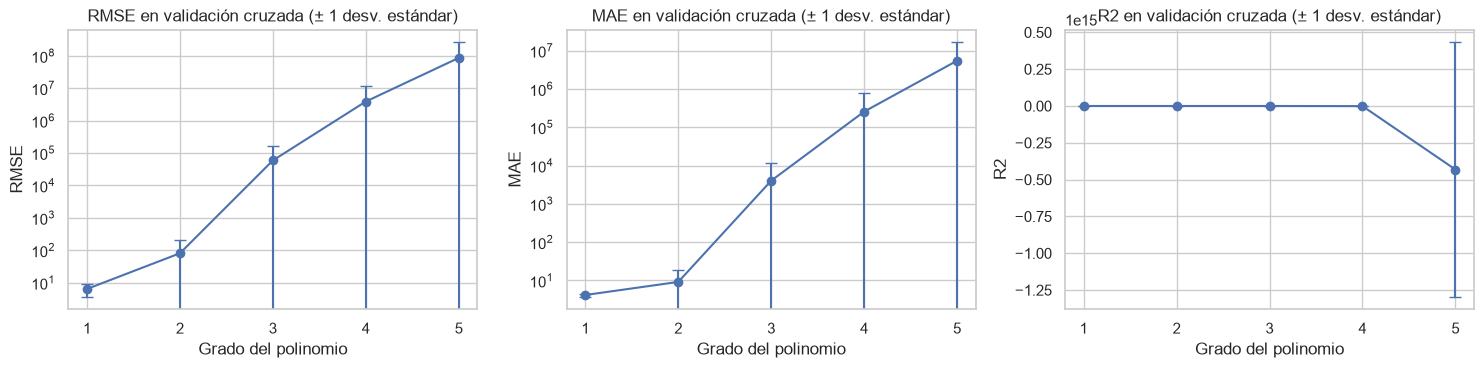

In [28]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

especificacion_metricas = [
    ("RMSE_cv_media", "RMSE_cv_std", "RMSE"),
    ("MAE_cv_media", "MAE_cv_std", "MAE"),
    ("R2_cv_media", "R2_cv_std", "R2"),
]

for eje, (col_media, col_std, etiqueta) in zip(ejes, especificacion_metricas):
    eje.errorbar(
        curva_poly["grado"], curva_poly[col_media], yerr=curva_poly[col_std],
        marker="o", capsize=4,
    )
    if etiqueta != "R2":
        eje.set_yscale("log")
    eje.set_xlabel("Grado del polinomio")
    eje.set_ylabel(etiqueta)
    eje.set_title(f"{etiqueta} en validación cruzada (± 1 desv. estándar)")
    eje.set_xticks(curva_poly["grado"])

plt.tight_layout()
plt.show()


RMSE y MAE se grafican en escala logarítmica porque su magnitud crece varios órdenes de manera entre un grado y el siguiente (ver `tabla_grid_poly`); en escala lineal los grados 1-2 serían indistinguibles frente a la explosión de los grados 4-5.

## 6.2 Entrenamiento vs. validación cruzada (sesgo-varianza)

La comparación anterior solo usa el error de validación cruzada. Para diagnosticar sobreajuste en el sentido clásico (sesgo-varianza) hace falta también el error de **entrenamiento** por grado, que `GridSearchCV` no guarda por defecto. Se recalcula con `validation_curve`, variando únicamente el grado y fijando el escalador ganador — sin tocar `X_test` en ningún momento.

In [32]:
modelo_poly_curva = clone(modelo_poly).set_params(
    preprocesamiento__numericas__escalador=grid_poly.best_params_["preprocesamiento__numericas__escalador"]
)

grados_curva = [1, 2, 3, 4, 5]

train_scores_poly, cv_scores_poly = validation_curve(
    modelo_poly_curva, X_train, y_train,
    param_name="preprocesamiento__numericas__polinomiales__degree",
    param_range=grados_curva,
    cv=KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

tabla_sesgo_varianza_poly = pd.DataFrame({
    "grado": grados_curva,
    "RMSE_entrenamiento_media": -train_scores_poly.mean(axis=1),
    "RMSE_entrenamiento_std": train_scores_poly.std(axis=1),
    "RMSE_cv_media": -cv_scores_poly.mean(axis=1),
    "RMSE_cv_std": cv_scores_poly.std(axis=1),
})
tabla_sesgo_varianza_poly["brecha_cv_menos_train"] = (
    tabla_sesgo_varianza_poly["RMSE_cv_media"] - tabla_sesgo_varianza_poly["RMSE_entrenamiento_media"]
)
tabla_sesgo_varianza_poly.round(4)


,grado,RMSE_entrenamiento_media,RMSE_entrenamiento_std,RMSE_cv_media,RMSE_cv_std,brecha_cv_menos_train
0,1,4.9033,0.0413,6.348900e+00,2.649600e+00,1.445600e+00
1,2,3.5297,0.0330,8.023620e+01,1.261747e+02,7.670650e+01
2,3,0.0000,0.0000,5.884030e+04,1.083200e+05,5.884030e+04
3,4,0.0250,0.0430,3.875356e+06,7.738208e+06,3.875356e+06
4,5,2.5217,0.5178,8.618509e+07,1.719258e+08,8.618509e+07


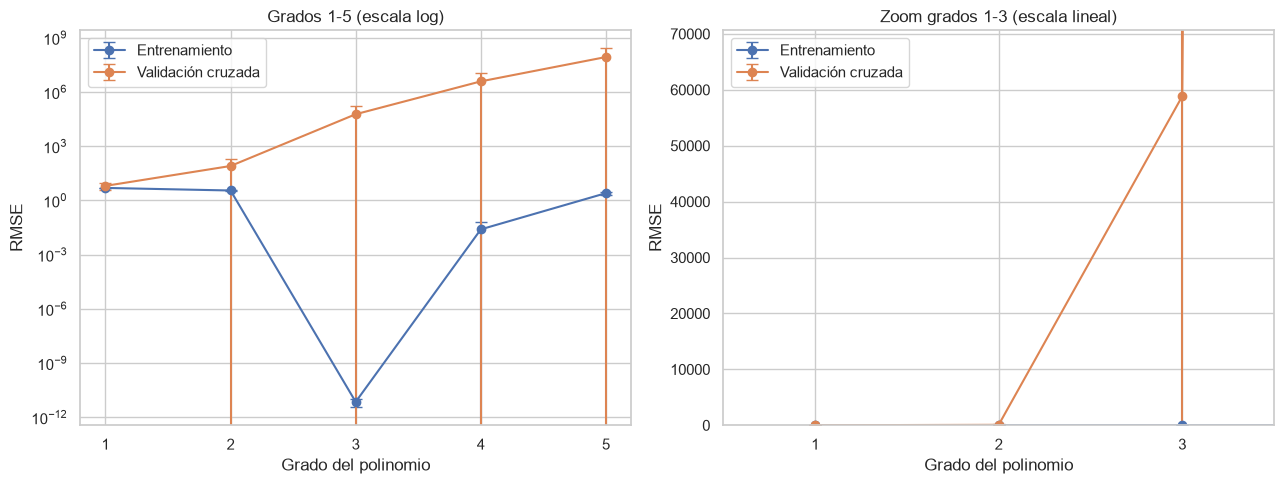

In [33]:
fig, (eje_completo, eje_zoom) = plt.subplots(1, 2, figsize=(13, 5))

for eje in (eje_completo, eje_zoom):
    eje.errorbar(
        tabla_sesgo_varianza_poly["grado"], tabla_sesgo_varianza_poly["RMSE_entrenamiento_media"],
        yerr=tabla_sesgo_varianza_poly["RMSE_entrenamiento_std"],
        marker="o", capsize=4, label="Entrenamiento",
    )
    eje.errorbar(
        tabla_sesgo_varianza_poly["grado"], tabla_sesgo_varianza_poly["RMSE_cv_media"],
        yerr=tabla_sesgo_varianza_poly["RMSE_cv_std"],
        marker="o", capsize=4, label="Validación cruzada",
    )
    eje.set_xlabel("Grado del polinomio")
    eje.set_ylabel("RMSE")
    eje.set_xticks(tabla_sesgo_varianza_poly["grado"])
    eje.legend()

eje_completo.set_yscale("log")
eje_completo.set_title("Grados 1-5 (escala log)")

grados_zoom = tabla_sesgo_varianza_poly["grado"] <= 3
eje_zoom.set_xlim(0.5, 3.5)
eje_zoom.set_ylim(
    0,
    tabla_sesgo_varianza_poly.loc[grados_zoom, ["RMSE_entrenamiento_media", "RMSE_cv_media"]].to_numpy().max() * 1.2,
)
eje_zoom.set_title("Zoom grados 1-3 (escala lineal)")

plt.tight_layout()
plt.show()


**Interpretación:** *(completar después de ejecutar, usando `tabla_sesgo_varianza_poly` y las dos gráficas: describir cómo evoluciona el error de entrenamiento frente al de validación cruzada a medida que aumenta el grado, identificar a partir de qué grado la brecha entre ambos se dispara —ese es el punto de sobreajuste—, y relacionar el hallazgo con el trade-off sesgo-varianza: un grado bajo con error de entrenamiento y de CV similares pero altos indica sesgo; un grado alto con error de entrenamiento bajo pero de CV disparado indica varianza excesiva.)*

# 7. Modelos regularizados — Ridge y Lasso

**Actividad 3.** Pipelines con regularización L2 (Ridge) y L1 (Lasso), incluyendo el parámetro de penalización y la estrategia de escalamiento como hiperparámetros de `GridSearchCV`. Se compara el desempeño frente al modelo sin regularización (el OLS de la sección 5, grado 1) y se analiza el efecto de la penalización sobre la generalización y la magnitud de los coeficientes. Para Lasso se examina además qué variables son llevadas a cero.

## 7.1 Selección de variables y pipeline base

Se reutilizan las mismas variables de la sección 5 (23 numéricas + `estacion_reconstruida`/`sector_viento`), pero **sin** `PolynomialFeatures`: aquí se evalúa el efecto de la regularización sobre el modelo lineal original, no sobre una versión expandida (esa combinación es la actividad 4, sección 8).

In [34]:
variables_numericas_reg = variables_numericas_poly
variables_categoricas_reg = variables_categoricas_poly

transformador_numerico_reg = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

transformador_categorico_reg = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocesamiento_reg = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico_reg, variables_numericas_reg),
    ("categoricas", transformador_categorico_reg, variables_categoricas_reg),
])

modelo_ridge = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_reg),
    ("regresion", Ridge()),
])

modelo_lasso = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_reg),
    ("regresion", Lasso(max_iter=20000)),
])

alphas_regularizacion = np.logspace(-3, 3, 13)
print("Valores de alpha evaluados:", alphas_regularizacion)


Valores de alpha evaluados: [1.00000000e-03 3.16227766e-03 1.00000000e-02 3.16227766e-02
 1.00000000e-01 3.16227766e-01 1.00000000e+00 3.16227766e+00
 1.00000000e+01 3.16227766e+01 1.00000000e+02 3.16227766e+02
 1.00000000e+03]


## 7.2 Búsqueda de hiperparámetros — Ridge

In [37]:
param_grid_ridge = {
    "preprocesamiento__numericas__escalador": [StandardScaler(), MinMaxScaler()],
    "regresion__alpha": alphas_regularizacion,
}

grid_ridge = GridSearchCV(
    modelo_ridge,
    param_grid=param_grid_ridge,
    cv=KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE),
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    refit="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_ridge.fit(X_train, y_train)

print("Mejores hiperparámetros (Ridge):", grid_ridge.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_ridge.best_score_:.4f}")


Mejores hiperparámetros (Ridge): {'preprocesamiento__numericas__escalador': MinMaxScaler(), 'regresion__alpha': np.float64(10.0)}
Mejor RMSE promedio en validación cruzada: 5.1130


## 7.3 Búsqueda de hiperparámetros — Lasso

In [38]:
param_grid_lasso = {
    "preprocesamiento__numericas__escalador": [StandardScaler(), MinMaxScaler()],
    "regresion__alpha": alphas_regularizacion,
}

grid_lasso = GridSearchCV(
    modelo_lasso,
    param_grid=param_grid_lasso,
    cv=KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE),
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    refit="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid_lasso.fit(X_train, y_train)

print("Mejores hiperparámetros (Lasso):", grid_lasso.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_lasso.best_score_:.4f}")


Mejores hiperparámetros (Lasso): {'preprocesamiento__numericas__escalador': MinMaxScaler(), 'regresion__alpha': np.float64(0.0031622776601683794)}
Mejor RMSE promedio en validación cruzada: 5.0359


## 7.4 Resultados de la búsqueda

In [39]:
def construir_tabla_grid(grid, nombre_hiperparametro, columna_param):
    resultados = pd.DataFrame(grid.cv_results_)
    tabla = pd.DataFrame({
        nombre_hiperparametro: resultados[columna_param],
        "escalador": resultados["param_preprocesamiento__numericas__escalador"].astype(str),
        "RMSE_cv_media": -resultados["mean_test_neg_root_mean_squared_error"],
        "RMSE_cv_std": resultados["std_test_neg_root_mean_squared_error"],
        "MAE_cv_media": -resultados["mean_test_neg_mean_absolute_error"],
        "MAE_cv_std": resultados["std_test_neg_mean_absolute_error"],
        "R2_cv_media": resultados["mean_test_r2"],
        "R2_cv_std": resultados["std_test_r2"],
    }).sort_values("RMSE_cv_media").reset_index(drop=True)
    return tabla


tabla_grid_ridge = construir_tabla_grid(grid_ridge, "alpha", "param_regresion__alpha")
tabla_grid_ridge.round(4).head(10)


,alpha,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,10.0000,MinMaxScaler(),5.1130,0.2548,4.0485,0.1651,0.6826,0.0240
1,3.1623,MinMaxScaler(),5.1622,0.3612,4.0344,0.1748,0.6761,0.0370
2,31.6228,MinMaxScaler(),5.2553,0.2680,4.1558,0.1845,0.6646,0.0262
3,1.0000,MinMaxScaler(),5.4712,0.9478,4.0726,0.2350,0.6288,0.1287
4,100.0000,MinMaxScaler(),5.7666,0.2701,4.5977,0.2170,0.5963,0.0274
5,0.3162,MinMaxScaler(),5.9011,1.7813,4.1197,0.3063,0.5452,0.2931
6,0.1000,MinMaxScaler(),6.1756,2.3138,4.1474,0.3497,0.4811,0.4194
7,0.0316,MinMaxScaler(),6.2901,2.5356,4.1588,0.3677,0.4519,0.4769
8,0.0100,MinMaxScaler(),6.3299,2.6127,4.1627,0.3739,0.4414,0.4976
9,3.1623,StandardScaler(),6.3398,2.6341,4.1641,0.3774,0.4387,0.5032


In [40]:
tabla_grid_lasso = construir_tabla_grid(grid_lasso, "alpha", "param_regresion__alpha")
tabla_grid_lasso.round(4).head(10)


,alpha,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,0.0032,MinMaxScaler(),5.0359,0.1927,3.9980,0.1365,0.6922,0.0167
1,0.0100,MinMaxScaler(),5.0362,0.2035,3.9976,0.1412,0.6921,0.0185
2,0.0316,MinMaxScaler(),5.0809,0.2420,4.0270,0.1639,0.6865,0.0239
3,0.1000,StandardScaler(),5.0867,0.2168,4.0425,0.1344,0.6859,0.0191
4,0.1000,MinMaxScaler(),5.2593,0.2780,4.1639,0.1967,0.6639,0.0297
5,0.0010,MinMaxScaler(),5.4583,0.9181,4.0764,0.2324,0.6311,0.1238
6,0.3162,StandardScaler(),5.6390,0.2490,4.4666,0.2044,0.6140,0.0246
7,0.0316,StandardScaler(),5.7048,1.4291,4.0958,0.2721,0.5850,0.2184
8,0.3162,MinMaxScaler(),5.8184,0.2993,4.6227,0.2426,0.5887,0.0347
9,0.0100,StandardScaler(),6.1250,2.2435,4.1373,0.3397,0.4921,0.4012


## 7.5 Comparación frente al modelo sin regularización

Se compara la mejor combinación de cada familia (OLS de la sección 5, Ridge y Lasso) usando únicamente sus métricas de validación cruzada — todavía sin tocar `X_test`.

In [41]:
resumen_cv_ridge = tabla_grid_ridge.iloc[[0]].copy()
resumen_cv_ridge.insert(0, "modelo", "Ridge")

resumen_cv_lasso = tabla_grid_lasso.iloc[[0]].copy()
resumen_cv_lasso.insert(0, "modelo", "Lasso")

columnas_comunes = ["modelo", "RMSE_cv_media", "RMSE_cv_std", "MAE_cv_media", "MAE_cv_std", "R2_cv_media", "R2_cv_std"]

comparacion_regularizacion = pd.concat([
    resumen_cv_poly.assign(modelo="Sin regularizar (OLS)")[columnas_comunes],
    resumen_cv_ridge[columnas_comunes],
    resumen_cv_lasso[columnas_comunes],
], ignore_index=True)

comparacion_regularizacion.round(4)


,modelo,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,Sin regularizar (OLS),6.3489,2.6496,4.1646,0.3769,0.4363,0.5076
1,Ridge,5.1130,0.2548,4.0485,0.1651,0.6826,0.0240
2,Lasso,5.0359,0.1927,3.9980,0.1365,0.6922,0.0167


## 7.6 Estabilidad por fold

La tabla anterior ya muestra que `RMSE_cv_std` baja notablemente al regularizar. Para verlo con más detalle, se extraen los 5 valores de RMSE por fold (guardados por `GridSearchCV` en `cv_results_`, sin necesidad de volver a entrenar nada) de la mejor combinación de cada familia.

In [42]:
def obtener_rmse_por_fold(grid, indice=None):
    indice = grid.best_index_ if indice is None else indice
    columnas_fold = sorted(
        (c for c in grid.cv_results_ if c.startswith("split") and c.endswith("test_neg_root_mean_squared_error")),
        key=lambda c: int(c.split("_")[0].replace("split", "")),
    )
    return np.array([-grid.cv_results_[c][indice] for c in columnas_fold])


tabla_estabilidad_folds = pd.DataFrame({
    "Sin regularizar (OLS)": obtener_rmse_por_fold(grid_poly),
    "Ridge": obtener_rmse_por_fold(grid_ridge),
    "Lasso": obtener_rmse_por_fold(grid_lasso),
})
tabla_estabilidad_folds.round(4)


,Sin regularizar (OLS),Ridge,Lasso
0,5.4197,5.4875,5.3495
1,4.9109,4.9734,4.9198
2,11.6319,5.3372,5.1591
3,4.9610,4.9510,4.9359
4,4.8211,4.8159,4.8151


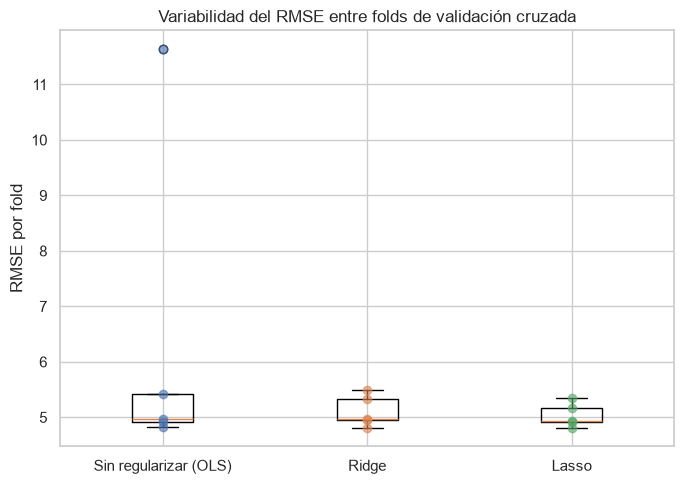

In [43]:
plt.figure(figsize=(7, 5))
plt.boxplot(
    [tabla_estabilidad_folds[col] for col in tabla_estabilidad_folds.columns],
    tick_labels=tabla_estabilidad_folds.columns,
)
for i, col in enumerate(tabla_estabilidad_folds.columns, start=1):
    plt.scatter([i] * len(tabla_estabilidad_folds), tabla_estabilidad_folds[col], alpha=0.6, zorder=3)
plt.ylabel("RMSE por fold")
plt.title("Variabilidad del RMSE entre folds de validación cruzada")
plt.tight_layout()
plt.show()


## 7.7 Variables llevadas a cero por el Lasso seleccionado

Se usa el modelo Lasso realmente elegido por `GridSearchCV` (su propio escalador y alpha ganadores), no una versión forzada, para responder qué variables fueron eliminadas.

In [44]:
nombres_variables_lasso = grid_lasso.best_estimator_.named_steps["preprocesamiento"].get_feature_names_out()
coeficientes_lasso = grid_lasso.best_estimator_.named_steps["regresion"].coef_

tabla_coeficientes_lasso = pd.DataFrame({
    "variable": [n.replace("numericas__", "").replace("categoricas__", "") for n in nombres_variables_lasso],
    "coeficiente": coeficientes_lasso,
})
tabla_coeficientes_lasso["en_cero"] = np.isclose(tabla_coeficientes_lasso["coeficiente"], 0)

variables_eliminadas_lasso = tabla_coeficientes_lasso.loc[tabla_coeficientes_lasso["en_cero"], "variable"].tolist()

print(f"Alpha seleccionado para Lasso: {grid_lasso.best_params_['regresion__alpha']:.5g}")
print(f"Variables llevadas a cero: {len(variables_eliminadas_lasso)} de {len(tabla_coeficientes_lasso)}")
print(variables_eliminadas_lasso)

tabla_coeficientes_lasso.sort_values("coeficiente", key=lambda s: s.abs()).reset_index(drop=True)


Alpha seleccionado para Lasso: 0.0031623
Variables llevadas a cero: 7 de 33
['presion_min', 'presion_max', 'viento_min', 'viento_desv', 'viento_este', 'registros_del_dia', 'mes_num']


,variable,coeficiente,en_cero
0,presion_min,-0.000000,True
1,presion_max,-0.000000,True
2,viento_desv,0.000000,True
3,viento_min,-0.000000,True
4,registros_del_dia,-0.000000,True
5,mes_num,0.000000,True
6,viento_este,-0.000000,True
7,sector_viento_SE,-0.057060,False
8,sector_viento_NE,-0.550525,False
9,presion_media,0.622741,False


**Interpretación (variables eliminadas):** *(completar: relacionar la lista anterior con la selección automática de características — por ejemplo, si varias son estadísticas redundantes de un mismo fenómeno (mínimo/máximo/desviación), discutir qué se gana y qué se pierde en interpretabilidad al quitarlas.)*

## 7.8 Magnitud de los coeficientes (comparación con escalador fijo)

Para comparar de forma justa la **magnitud** de los coeficientes entre OLS, Ridge y Lasso hace falta que los tres usen el mismo escalador — de lo contrario cada coeficiente estaría en una escala distinta y la comparación no sería válida (por eso esta tabla es adicional a la sección 7.7, que sí usa el Lasso realmente seleccionado). Se fija `StandardScaler` para los tres, conservando el alpha ganador de cada uno.

In [45]:
preprocesamiento_coef = ColumnTransformer(transformers=[
    ("numericas", Pipeline([("imputador", SimpleImputer(strategy="median")), ("escalador", StandardScaler())]), variables_numericas_reg),
    ("categoricas", Pipeline([("imputador", SimpleImputer(strategy="most_frequent")), ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first"))]), variables_categoricas_reg),
])

modelo_ols_coef = Pipeline([
    ("preprocesamiento", preprocesamiento_coef),
    ("regresion", LinearRegression()),
]).fit(X_train, y_train)

modelo_ridge_coef = Pipeline([
    ("preprocesamiento", clone(preprocesamiento_coef)),
    ("regresion", Ridge(alpha=grid_ridge.best_params_["regresion__alpha"])),
]).fit(X_train, y_train)

modelo_lasso_coef = Pipeline([
    ("preprocesamiento", clone(preprocesamiento_coef)),
    ("regresion", Lasso(alpha=grid_lasso.best_params_["regresion__alpha"], max_iter=20000)),
]).fit(X_train, y_train)

nombres_variables_reg = modelo_ols_coef.named_steps["preprocesamiento"].get_feature_names_out()

tabla_comparacion_coeficientes = pd.DataFrame({
    "variable": [n.replace("numericas__", "").replace("categoricas__", "") for n in nombres_variables_reg],
    "OLS": modelo_ols_coef.named_steps["regresion"].coef_,
    "Ridge": modelo_ridge_coef.named_steps["regresion"].coef_,
    "Lasso": modelo_lasso_coef.named_steps["regresion"].coef_,
})
tabla_comparacion_coeficientes = tabla_comparacion_coeficientes.sort_values(
    "OLS", key=lambda s: s.abs(), ascending=False
).reset_index(drop=True)
tabla_comparacion_coeficientes.round(4)


,variable,OLS,Ridge,Lasso
0,estacion_reconstruida_verano,13.9357,12.6036,13.8470
1,estacion_reconstruida_otono,7.4143,6.2987,7.3292
2,estacion_reconstruida_primavera,6.9931,5.9431,6.9105
3,sector_viento_NO,-2.5077,-1.0291,-1.3392
4,humedad_media,-2.1831,-2.0765,-2.1380
5,humedad_desv,2.1461,2.2846,2.1582
6,sector_viento_S,-2.0604,-1.1761,-1.2299
7,sector_viento_SO,-1.9357,-0.8421,-1.0033
8,sector_viento_O,-1.7068,-0.4535,-0.6667
9,viento_norte,-1.5553,-1.4728,-1.5877


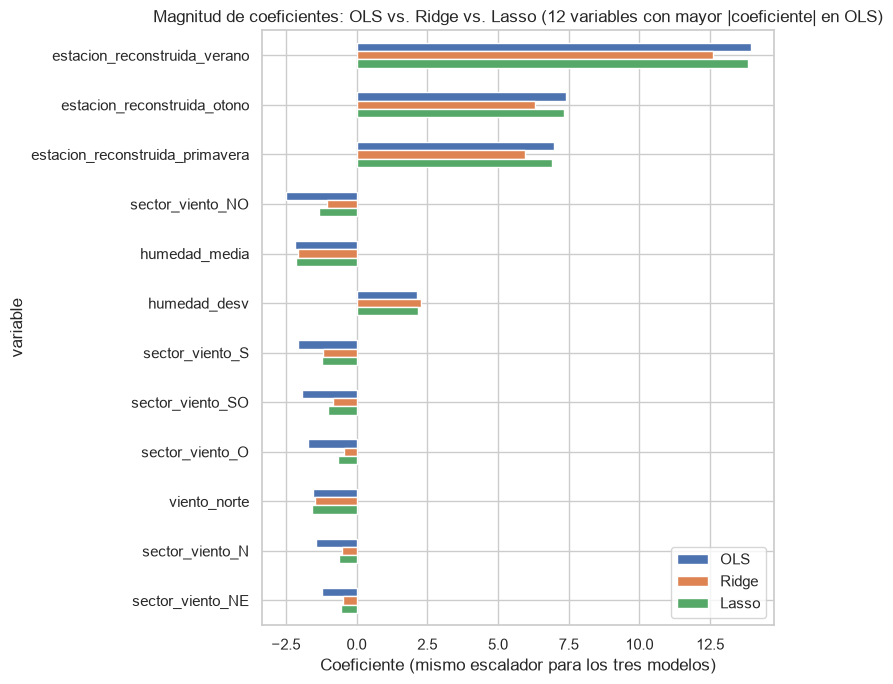

In [46]:
top_variables = tabla_comparacion_coeficientes.head(12).set_index("variable")

top_variables.plot(kind="barh", figsize=(8, 7))
plt.xlabel("Coeficiente (mismo escalador para los tres modelos)")
plt.title("Magnitud de coeficientes: OLS vs. Ridge vs. Lasso (12 variables con mayor |coeficiente| en OLS)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:** *(completar después de ejecutar: comparar `comparacion_regularizacion` — RMSE/estabilidad de OLS vs. Ridge vs. Lasso —, relacionar con `tabla_estabilidad_folds` y el boxplot para explicar por qué la regularización mejora la generalización aquí (pista: revisar si algún fold de OLS es mucho peor que los demás), y usar `tabla_comparacion_coeficientes` para describir cómo Ridge y Lasso reducen la magnitud de los coeficientes frente a OLS, especialmente en las variables categóricas.)*

# 8. Modelo polinomial regularizado

**Actividad 4.** Pipeline que combina características polinomiales con un modelo regularizado, explorando conjuntamente grado, penalización y escalamiento. Se evalúa con RMSE, MAE y R² por validación cruzada, y se discute si la regularización controla el sobreajuste al incrementar la complejidad.

## 8.1 Por qué Ridge y no Lasso para esta combinación

Antes de correr el grid completo se probó cuánto tarda un solo modelo con cada método, usando las mismas variables pero ya con el polinomio agregado:

| Modelo | Grado 3 (2599 columnas) | Grado 4 (17 549 columnas) |
|---|---:|---:|
| Ridge | 0.2 s | 0.7 s |
| Lasso | 15.8 s | 106.0 s |

Con tantas columnas, Lasso resultó cerca de 150 veces más lento que Ridge, y en el grado más alto ni siquiera terminó de ajustarse del todo (scikit-learn avisó que no convergió, es decir, que no alcanzó a encontrar una solución estable en el número de intentos permitido). Multiplicando eso por todas las combinaciones de grado, penalización y escalador que hay que probar, un grid completo con Lasso tomaría horas en vez de minutos. Por eso esta actividad se hace con Ridge.

## 8.2 Selección de variables y pipeline

Mismas variables que en las secciones 5 y 7 (23 numéricas + `estacion_reconstruida`/`sector_viento`), combinando `PolynomialFeatures` (como en la sección 5) con `Ridge` (como en la sección 7).

In [47]:
transformador_numerico_poly_reg = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("polinomiales", PolynomialFeatures(include_bias=False)),
])

transformador_categorico_poly_reg = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocesamiento_poly_reg = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico_poly_reg, variables_numericas_poly),
    ("categoricas", transformador_categorico_poly_reg, variables_categoricas_poly),
])

modelo_poly_reg = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly_reg),
    ("regresion", Ridge()),
])


## 8.3 Búsqueda de hiperparámetros

Se exploran los grados 1 a 4 (se excluye el grado 5: en la sección 5 ya se documentó que la tendencia de sobreajuste extremo continúa empeorando, y agregarlo aquí multiplicaría varias veces el tiempo de cómputo sin cambiar la conclusión), los mismos 13 valores de `alpha` de la sección 7 y los dos escaladores. Esto da 4×13×2 = 104 combinaciones × 5 folds = 520 ajustes.

**Nota de cómputo:** con `n_jobs=-1` (todos los núcleos en paralelo) esta búsqueda agotó los recursos del sistema — demasiados procesos pesados corriendo a la vez, cada uno manejando miles de columnas del grado más alto. Se usa `n_jobs=4` en su lugar, lo que la hace más lenta (~1 minuto) pero estable. Si en tu equipo también falla, baja `n_jobs` a 2 o incluso a 1.

In [48]:
param_grid_poly_reg = {
    "preprocesamiento__numericas__escalador": [StandardScaler(), MinMaxScaler()],
    "preprocesamiento__numericas__polinomiales__degree": [1, 2, 3, 4],
    "regresion__alpha": alphas_regularizacion,
}

grid_poly_reg = GridSearchCV(
    modelo_poly_reg,
    param_grid=param_grid_poly_reg,
    cv=KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=RANDOM_STATE),
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    refit="neg_root_mean_squared_error",
    n_jobs=4,
)

grid_poly_reg.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_poly_reg.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_poly_reg.best_score_:.4f}")


Mejores hiperparámetros: {'preprocesamiento__numericas__escalador': MinMaxScaler(), 'preprocesamiento__numericas__polinomiales__degree': 1, 'regresion__alpha': np.float64(10.0)}
Mejor RMSE promedio en validación cruzada: 5.1130


## 8.4 Resultados de la búsqueda

In [49]:
resultados_grid_poly_reg = pd.DataFrame(grid_poly_reg.cv_results_)

tabla_grid_poly_reg = pd.DataFrame({
    "grado": resultados_grid_poly_reg["param_preprocesamiento__numericas__polinomiales__degree"],
    "alpha": resultados_grid_poly_reg["param_regresion__alpha"],
    "escalador": resultados_grid_poly_reg["param_preprocesamiento__numericas__escalador"].astype(str),
    "RMSE_cv_media": -resultados_grid_poly_reg["mean_test_neg_root_mean_squared_error"],
    "RMSE_cv_std": resultados_grid_poly_reg["std_test_neg_root_mean_squared_error"],
    "MAE_cv_media": -resultados_grid_poly_reg["mean_test_neg_mean_absolute_error"],
    "MAE_cv_std": resultados_grid_poly_reg["std_test_neg_mean_absolute_error"],
    "R2_cv_media": resultados_grid_poly_reg["mean_test_r2"],
    "R2_cv_std": resultados_grid_poly_reg["std_test_r2"],
}).sort_values("RMSE_cv_media").reset_index(drop=True)

tabla_grid_poly_reg.round(4).head(10)


,grado,alpha,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,1,10.0000,MinMaxScaler(),5.1130,0.2548,4.0485,0.1651,0.6826,0.0240
1,1,3.1623,MinMaxScaler(),5.1622,0.3612,4.0344,0.1748,0.6761,0.0370
2,1,31.6228,MinMaxScaler(),5.2553,0.2680,4.1558,0.1845,0.6646,0.0262
3,1,1.0000,MinMaxScaler(),5.4712,0.9478,4.0726,0.2350,0.6288,0.1287
4,2,3.1623,MinMaxScaler(),5.5210,1.4214,3.6674,0.2539,0.6109,0.1871
5,2,100.0000,MinMaxScaler(),5.5939,0.6455,4.2986,0.2240,0.6172,0.0827
6,1,100.0000,MinMaxScaler(),5.7666,0.2701,4.5977,0.2170,0.5963,0.0274
7,1,0.3162,MinMaxScaler(),5.9011,1.7813,4.1197,0.3063,0.5452,0.2931
8,2,31.6228,MinMaxScaler(),6.0205,2.2339,4.0231,0.3402,0.5080,0.3931
9,2,316.2278,MinMaxScaler(),6.0310,0.3107,4.8346,0.2085,0.5584,0.0342


## 8.5 ¿La regularización controla el sobreajuste al aumentar el grado?

Para cada grado se toma la mejor combinación de alpha/escalador (la de menor RMSE de CV) y se compara contra el modelo sin regularizar de la misma sección de grados (`curva_poly`, sección 6.1).

In [50]:
mejor_por_grado_poly_reg = (
    tabla_grid_poly_reg.sort_values("RMSE_cv_media")
    .groupby("grado", as_index=False)
    .first()
    .sort_values("grado")
    .reset_index(drop=True)
)
mejor_por_grado_poly_reg[["grado", "alpha", "escalador", "RMSE_cv_media", "RMSE_cv_std"]]


,grado,alpha,escalador,RMSE_cv_media,RMSE_cv_std
0,1,10.000000,MinMaxScaler(),5.112993,0.254764
1,2,3.162278,MinMaxScaler(),5.520984,1.421418
2,3,1000.000000,MinMaxScaler(),9.687479,7.180471
3,4,1000.000000,MinMaxScaler(),152.611260,290.925996


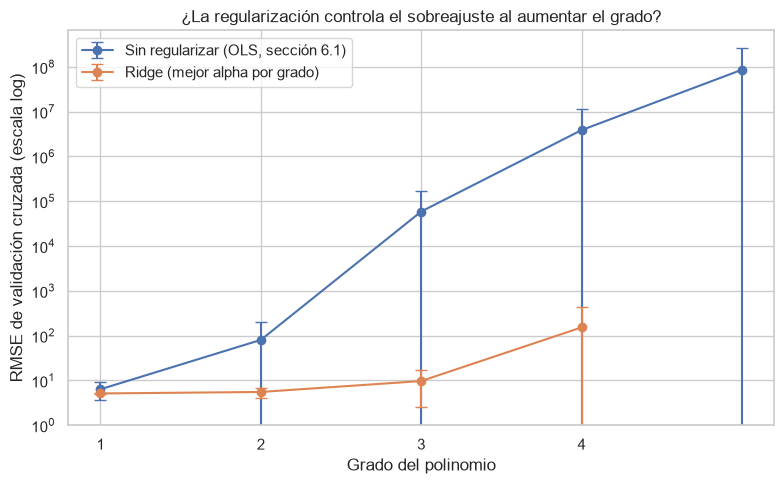

In [51]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    curva_poly["grado"], curva_poly["RMSE_cv_media"], yerr=curva_poly["RMSE_cv_std"],
    marker="o", capsize=4, label="Sin regularizar (OLS, sección 6.1)",
)
plt.errorbar(
    mejor_por_grado_poly_reg["grado"], mejor_por_grado_poly_reg["RMSE_cv_media"],
    yerr=mejor_por_grado_poly_reg["RMSE_cv_std"],
    marker="o", capsize=4, label="Ridge (mejor alpha por grado)",
)
plt.yscale("log")
plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE de validación cruzada (escala log)")
plt.title("¿La regularización controla el sobreajuste al aumentar el grado?")
plt.xticks(mejor_por_grado_poly_reg["grado"])
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación:** *(completar después de ejecutar. Algunas pistas a partir de `mejor_por_grado_poly_reg`: comparar cuántos órdenes de magnitud reduce Ridge el RMSE de CV frente a `curva_poly` en cada grado —la regularización sí atenúa la explosión, pero no la elimina—; revisar si el `alpha` ganador en los grados más altos coincide con el límite superior de la malla probada (lo que sugeriría que ni siquiera la penalización más fuerte evaluada alcanza a compensar del todo esa complejidad); y concluir si, aun así, el grado 1 sigue siendo preferible en este conjunto de datos.)*

## 8.6 Resumen para la comparación final

In [52]:
resumen_cv_poly_reg = tabla_grid_poly_reg.iloc[[0]].copy()
resumen_cv_poly_reg.insert(0, "modelo", "Polinomial regularizado (Ridge)")
resumen_cv_poly_reg


,modelo,grado,alpha,escalador,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,Polinomial regularizado (Ridge),1,10.0,MinMaxScaler(),5.112993,0.254764,4.048497,0.165103,0.682563,0.023974


# 9. Comparación y selección del mejor modelo

**Actividad 5.** Se comparan los modelos de las actividades 1, 3 y 4 considerando tanto el promedio de la métrica principal como su estabilidad (desviación estándar en validación cruzada). Se reportan los mejores hiperparámetros de cada uno y se argumenta la elección final.

## 9.1 Consolidación de resultados de validación cruzada

Se reutilizan los resúmenes ya guardados en cada sección (`resumen_cv_poly`, `resumen_cv_ridge`, `resumen_cv_lasso`, `resumen_cv_poly_reg`) — sin recalcular nada — para armar una sola tabla comparable.

In [58]:
def describir_hiperparametros(fila):
    partes = []
    if "grado" in fila.index and pd.notna(fila["grado"]):
        partes.append(f"grado={int(fila['grado'])}")
    if "alpha" in fila.index and pd.notna(fila["alpha"]):
        partes.append(f"alpha={fila['alpha']:.4g}")
    if "escalador" in fila.index and pd.notna(fila["escalador"]):
        partes.append(f"escalador={fila['escalador']}")
    return ", ".join(partes)


resumenes_finales = [resumen_cv_poly, resumen_cv_ridge, resumen_cv_lasso, resumen_cv_poly_reg]

tabla_comparacion_final = pd.DataFrame([
    {
        "modelo": resumen.iloc[0]["modelo"],
        "hiperparametros": describir_hiperparametros(resumen.iloc[0]),
        "RMSE_cv_media": resumen.iloc[0]["RMSE_cv_media"],
        "RMSE_cv_std": resumen.iloc[0]["RMSE_cv_std"],
        "MAE_cv_media": resumen.iloc[0]["MAE_cv_media"],
        "MAE_cv_std": resumen.iloc[0]["MAE_cv_std"],
        "R2_cv_media": resumen.iloc[0]["R2_cv_media"],
        "R2_cv_std": resumen.iloc[0]["R2_cv_std"],
    }
    for resumen in resumenes_finales
]).sort_values("RMSE_cv_media").reset_index(drop=True)

tabla_comparacion_final.round(4)


,modelo,hiperparametros,RMSE_cv_media,RMSE_cv_std,MAE_cv_media,MAE_cv_std,R2_cv_media,R2_cv_std
0,Lasso,"alpha=0.003162, escalador=MinMaxScaler()",5.0359,0.1927,3.9980,0.1365,0.6922,0.0167
1,Ridge,"alpha=10, escalador=MinMaxScaler()",5.1130,0.2548,4.0485,0.1651,0.6826,0.0240
2,Polinomial regularizado (Ridge),"grado=1, alpha=10, escalador=MinMaxScaler()",5.1130,0.2548,4.0485,0.1651,0.6826,0.0240
3,Polinomial,"grado=1, escalador=StandardScaler()",6.3489,2.6496,4.1646,0.3769,0.4363,0.5076


## 9.2 Selección según el criterio de la actividad (media y estabilidad de CV)

El criterio pedido no es solo el promedio: hay que revisar también `RMSE_cv_std`. Se identifica el modelo con menor RMSE promedio, pero la elección final (más abajo) debe confirmar si ese mismo modelo es también el más estable, o si hay que ponderar ambas cosas.

In [54]:
modelo_ganador_cv = tabla_comparacion_final.iloc[0]
print("Modelo con mejor RMSE promedio de CV:", modelo_ganador_cv["modelo"])
modelo_ganador_cv


Modelo con mejor RMSE promedio de CV: Lasso


modelo                                                Lasso
hiperparametros    alpha=0.003162, escalador=MinMaxScaler()
RMSE_cv_media                                      5.035876
RMSE_cv_std                                        0.192743
MAE_cv_media                                        3.99802
MAE_cv_std                                         0.136525
R2_cv_media                                        0.692177
R2_cv_std                                          0.016737
Name: 0, dtype: object

## 9.3 Evaluación en el conjunto de prueba (primera y única vez)

Hasta ahora ningún modelo había tocado `X_test`. Aquí, y solo aquí, se evalúan los cuatro candidatos ya fijados por CV — no se vuelve a ajustar ni a elegir nada con base en este resultado, es solo el reporte final.

In [55]:
resultados_test_todos = pd.concat([
    evaluar_modelo(grid_poly.best_estimator_, X_train, y_train, X_test, y_test, "Polinomial"),
    evaluar_modelo(grid_ridge.best_estimator_, X_train, y_train, X_test, y_test, "Ridge"),
    evaluar_modelo(grid_lasso.best_estimator_, X_train, y_train, X_test, y_test, "Lasso"),
    evaluar_modelo(grid_poly_reg.best_estimator_, X_train, y_train, X_test, y_test, "Polinomial regularizado (Ridge)"),
], ignore_index=True)

tabla_test_final = (
    resultados_test_todos[resultados_test_todos["Conjunto"] == "Prueba"]
    .drop(columns="Conjunto")
    .set_index("Modelo")
    .round(4)
)
tabla_test_final


,RMSE,MAE,R2
Modelo,,,
Polinomial,5.2739,4.1064,0.6342
Ridge,5.2566,4.0551,0.6366
Lasso,5.2690,4.0873,0.6348
Polinomial regularizado (Ridge),5.2566,4.0551,0.6366


## 9.4 ¿Coincide el mejor de CV con el mejor de prueba?

In [56]:
comparacion_cv_vs_test = tabla_comparacion_final.set_index("modelo")[["RMSE_cv_media", "RMSE_cv_std"]].join(
    tabla_test_final[["RMSE"]].rename(columns={"RMSE": "RMSE_test"})
)
comparacion_cv_vs_test["ranking_cv"] = comparacion_cv_vs_test["RMSE_cv_media"].rank()
comparacion_cv_vs_test["ranking_test"] = comparacion_cv_vs_test["RMSE_test"].rank()
comparacion_cv_vs_test.round(4)


,RMSE_cv_media,RMSE_cv_std,RMSE_test,ranking_cv,ranking_test
modelo,,,,,
Lasso,5.0359,0.1927,5.2690,1.0,3.0
Ridge,5.1130,0.2548,5.2566,2.5,1.5
Polinomial regularizado (Ridge),5.1130,0.2548,5.2566,2.5,1.5
Polinomial,6.3489,2.6496,5.2739,4.0,4.0


**Interpretación:** *(completar: ¿el modelo con mejor RMSE promedio de CV es también el mejor en `RMSE_test`? Si el orden cambia, recordar que `X_test` es una sola muestra de 614 filas mientras que la media de CV promedia 5 particiones distintas — con eso en mente, discutir cuál de las dos estimaciones te parece más confiable para decidir.)*

## 9.5 Selección final

Se guarda el modelo ganador (según el criterio de CV de la sección 9.2) como `modelo_final`, para usarlo en el bootstrapping de la sección 10.

In [57]:
mapa_modelos_finales = {
    "Polinomial": grid_poly.best_estimator_,
    "Ridge": grid_ridge.best_estimator_,
    "Lasso": grid_lasso.best_estimator_,
    "Polinomial regularizado (Ridge)": grid_poly_reg.best_estimator_,
}

nombre_modelo_final = modelo_ganador_cv["modelo"]
modelo_final = mapa_modelos_finales[nombre_modelo_final]

print("Modelo final seleccionado:", nombre_modelo_final)
print("Hiperparámetros:", modelo_ganador_cv["hiperparametros"])


Modelo final seleccionado: Lasso
Hiperparámetros: alpha=0.003162, escalador=MinMaxScaler()


**Justificación de la elección final:** *(completar, considerando conjuntamente:*
- *Desempeño: comparar `RMSE_cv_media` y `RMSE_test` de `modelo_final` contra los demás candidatos en `tabla_comparacion_final` y `tabla_test_final`.*
- *Estabilidad: comparar `RMSE_cv_std` — no basta con ganar en promedio si la variabilidad entre folds es alta (ver también la sección 7.6).*
- *Complejidad/interpretabilidad: si el modelo elegido es Lasso, recordar que además elimina variables (sección 7.7), lo que lo hace más simple de explicar que Ridge o el polinomial; si es otro modelo, comentar cuántas variables usa y qué tan fácil es interpretar sus coeficientes.)*

# 10. Intervalos de confianza (bootstrapping)

**Actividad 6.** Con el modelo seleccionado, aplicar bootstrapping sobre el conjunto de prueba (al menos 500 remuestreos) para estimar intervalos de confianza al 95% de RMSE, MAE y R². Graficar la distribución de los errores y discutir estabilidad, variabilidad y confiabilidad de las predicciones.

*(Pendiente de desarrollar.)*

# 11. Análisis de resultados

## 11.1 Análisis cuantitativo

- ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?
- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?
- ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.
- Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?
- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
- ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

*(Pendiente de desarrollar.)*

## 11.2 Análisis cualitativo

- ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?
- ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?
- ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?
- ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?
- ¿Mayor precisión implica necesariamente mayor valor para la organización?
- ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

*(Pendiente de desarrollar.)*

## 11.3 Reflexión conceptual

- ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?
- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?
- Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.

*(Pendiente de desarrollar.)*

# 12. Conclusiones

*(Pendiente de desarrollar.)*

# 13. Guion del video

**Actividad 7.** Guion de apoyo para el video explicativo (máximo 3 minutos), dirigido al ingeniero de machine learning que lidera el grupo de AlpesPlanck.

## Parte 1 — Modelado y selección (secciones 1 a 9)

*Borrador listo para grabar; ajusten el tono/palabras a como hablen ustedes. Con los números reales que arrojó la corrida, dura aproximadamente 1:30-1:40 min a ritmo normal.*

> Este video resume la comparación de modelos de regresión para predecir la temperatura máxima en AlpesPlanck, usando el mismo dataset limpio del laboratorio anterior.
>
> Empezamos con un modelo polinomial, buscando el grado óptimo por validación cruzada. El resultado fue contundente: el grado 1, es decir, sin ninguna expansión, fue el mejor, con un RMSE de 6.35°C. Desde el grado 2 el error se dispara varios órdenes de magnitud. Tenemos 23 variables meteorológicas, muchas redundantes entre sí —mínimos, máximos y desviaciones del mismo fenómeno—, así que agregar potencias e interacciones solo agrega ruido. Las curvas de validación lo confirman: el error de entrenamiento baja con la complejidad, pero el de validación se dispara — la firma clásica del sobreajuste.
>
> Después probamos regularización. Ridge y Lasso mejoraron notablemente el desempeño frente al modelo sin regularizar: el RMSE bajó a cerca de 5.1, y la variabilidad entre particiones de validación cruzada cayó de 2.65 a menos de 0.25. Descubrimos que el modelo sin regularizar tenía un fold catastrófico por multicolinealidad severa, y que incluso una penalización pequeña lo estabiliza por completo. Lasso, además, eliminó automáticamente 7 de 33 variables sin perder desempeño, simplificando el modelo.
>
> Al combinar el polinomio con Ridge confirmamos que la regularización atenúa la explosión del error, pero no la elimina — el grado 1 sigue siendo el más adecuado.
>
> Comparando los cuatro enfoques por validación cruzada, el ganador fue Lasso: mejor RMSE promedio, menor desviación estándar, y el más simple de interpretar.

## Parte 2 — Intervalos de confianza y análisis de resultados (secciones 10 y 11)

*(Pendiente: completar una vez se ejecuten el bootstrapping de la sección 10 y las respuestas de la sección 11, para citar los números reales de los intervalos de confianza y cerrar con las implicaciones prácticas para AlpesPlanck.)*

# 14. Uso de herramientas de IA generativa

## 14.1 Declaración de uso

**Herramienta utilizada:**

**Tipos de uso:**

## 14.2 Prompts principales

1. …

## 14.3 Análisis crítico del resultado

*(Responder al menos dos de las preguntas sugeridas en el enunciado.)*

## 14.4 Aportes propios de los estudiantes

*(Pendiente de desarrollar.)*